# Detection v1 — run & evaluate

Thin runner for the full cascade (L1 Stage1 → L2 Consolidator → L3 Classifier). Fits on the 90-recording
train split, checks the L3 window centring on the train split, evaluates on the 10 held-out test
recordings, saves the model. All logic lives in `src/` (`detect_config`, `detect_data`, `detection`,
`detect_metrics`); this notebook just wires it together.

**~5 min to run** (the L3 registration fit dominates; L1+L2 over all 90 recordings takes ~8 s).
Numbers are indicative — only ~5 test IEDs.

In [2]:
%load_ext autoreload
%autoreload 2
# ^ re-imports src/ on every cell run. Without it, editing detect_config.py or detect_metrics.py has no
#   effect until the kernel is restarted — silently, so a changed setting looks like it "did nothing".

import sys
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_CSV
from detect_data import load_dataset, stratified_split
from detection import Config, DetectionPipeline
import detect_metrics as M

cfg = Config()
man = load_CSV(Path('..') / 'Kural_Dataset' / 'eeg_summary.csv')
train_df, test_df = stratified_split(man, n_test=cfg.n_test, seed=cfg.split_seed)   # 90 / 10, deterministic
REC = Path('..') / 'Kural_Dataset' / 'Recordings'
train = load_dataset(train_df, REC)
test  = load_dataset(test_df, REC)
print(f"{len(train)} train / {len(test)} test  ({sum(r['epi'] for r in test)} test IEDs)")
print(f"config: grouping={cfg.grouping!r} corr={cfg.corr_threshold} centre_on={cfg.centre_on!r} "
      f"n_basis={cfg.n_basis} n_components={cfg.n_components}")

pipe = DetectionPipeline(cfg).fit(train)     # trains L3 on consolidated TRAIN candidates only
print('fit:', pipe.train_stats_)
pipe.save('../detect_model.joblib')          # shippable model (Config + fitted classifier)

90 train / 10 test  (5 test IEDs)
config: grouping='components' corr=0.7 centre_on='amplitude' n_basis=70 n_components=24
fit: {'windows': 4330, 'positives': 64}


## Window centring check (TRAIN only)

`event_window` re-centres each event before cutting the 2 s window the classifier sees. That choice is
potentially load-bearing: **Fisher-Rao registration is alignment-sensitive**, so if the re-centring lands
on the wrong extremum — an after-going slow wave, a baseline drift, the biphasic down-stroke — every FDA
feature is computed on a shifted curve, and L3's AUC would be depressed for a reason that has nothing to
do with the model. This section tests that.

`cfg.centre_on` picks the rule:
- `'amplitude'` — max |deviation from the local median| of the smoothed signal. Matches the annotation
  convention (marker at the spike peak) and how the classification-phase windows were cut, but the
  *largest* deflection near a spike is often the slow after-going component, not the spike.
- `'sharpness'` — max of the L1 statistic (|SG 2nd deriv| / MAD). Curvature peaks at the apex of a sharp
  transient, so a slow wave can't win.

Offsets below are measured against the **neurologist marker** (0 ms = the window centre sits exactly on
the annotated spike peak), over the 90-train only.

In [3]:
import numpy as np, matplotlib.pyplot as plt
from dataclasses import replace

off = {}                                  # centring rule -> (positive windows, offsets ms, recording ids)
for mode in ('amplitude', 'sharpness'):
    off[mode] = M.centring_offsets(DetectionPipeline(replace(cfg, centre_on=mode)), train)
    a = np.abs(off[mode][1])
    print(f"centre_on={mode:<10s} n={len(a):3d}   |offset| median {np.median(a):3.0f} ms  "
          f"p90 {np.percentile(a, 90):3.0f} ms  max {a.max():3.0f} ms   >100 ms: {(a > 100).mean():.0%}")

centre_on=amplitude  n= 64   |offset| median  26 ms  p90 133 ms  max 202 ms   >100 ms: 17%
centre_on=sharpness  n= 64   |offset| median  20 ms  p90  83 ms  max 152 ms   >100 ms: 2%


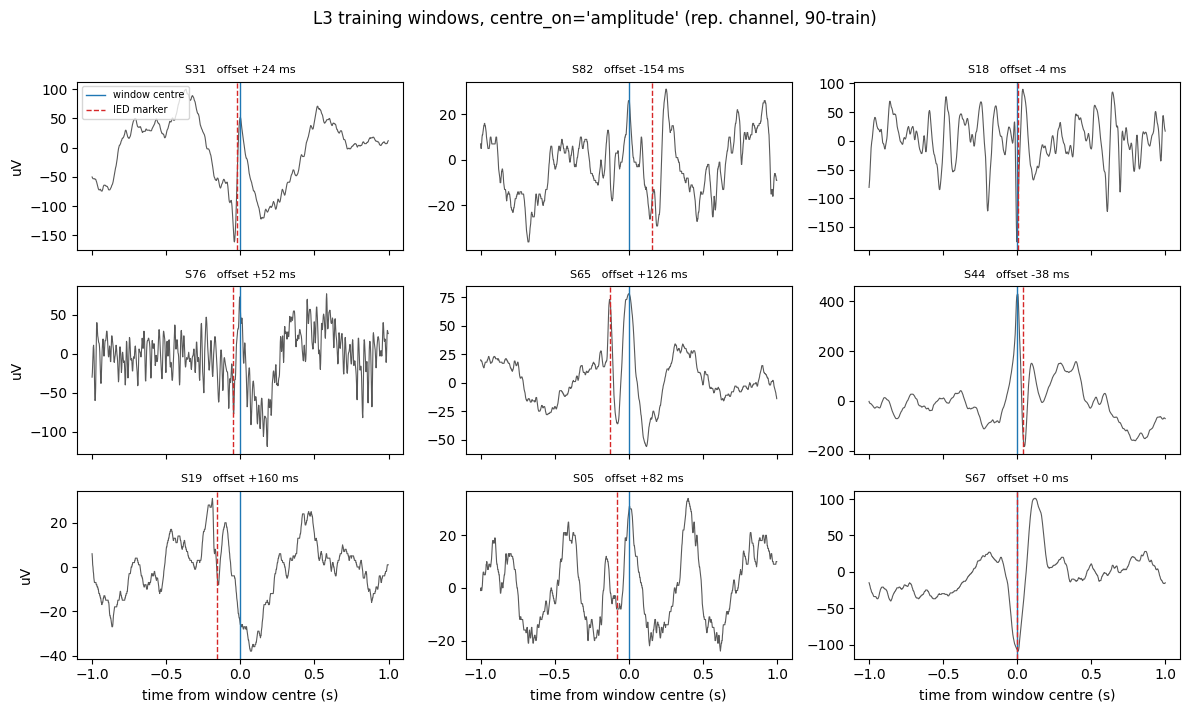

In [4]:
# eyeball 9 IED windows (one per recording) under the configured rule: centre should sit on the marker
W, offs, fids = off[cfg.centre_on]
seen, pick = set(), []
for i, f in enumerate(fids):
    if f not in seen:
        seen.add(f); pick.append(i)
t = (np.arange(W.shape[1]) - W.shape[1] // 2) / cfg.sfreq

fig, axs = plt.subplots(3, 3, figsize=(12, 7), sharex=True)
for ax, i in zip(axs.ravel(), pick[:9]):
    ax.plot(t, W[i], lw=0.8, color='0.35')
    ax.axvline(0, color='C0', lw=1.0, label='window centre')
    ax.axvline(-offs[i] / 1000, color='C3', ls='--', lw=1.0, label='IED marker')
    ax.set_title(f"{fids[i]}   offset {offs[i]:+.0f} ms", fontsize=8)
axs[0, 0].legend(fontsize=7, loc='upper left')
for ax in axs[-1]:
    ax.set_xlabel('time from window centre (s)')
for ax in axs[:, 0]:
    ax.set_ylabel('uV')
plt.suptitle(f"L3 training windows, centre_on='{cfg.centre_on}' (rep. channel, 90-train)", y=1.01)
plt.tight_layout()
plt.savefig(f'../figures/detection_window_centring_{cfg.centre_on}.png', dpi=800, bbox_inches='tight')
plt.show()

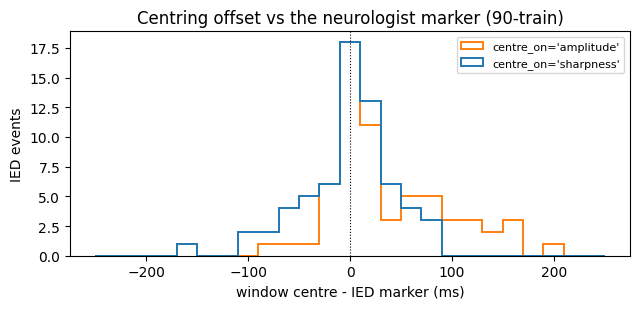

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
for mode, c in (('amplitude', 'C1'), ('sharpness', 'C0')):
    ax.hist(off[mode][1], bins=np.arange(-250, 251, 20), histtype='step', lw=1.4, color=c,
            label=f"centre_on='{mode}'")
ax.axvline(0, color='k', ls=':', lw=0.8)
ax.set_xlabel('window centre - IED marker (ms)'); ax.set_ylabel('IED events')
ax.set_title('Centring offset vs the neurologist marker (90-train)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/detection_centring_offsets.png', dpi=800, bbox_inches='tight')
plt.show()

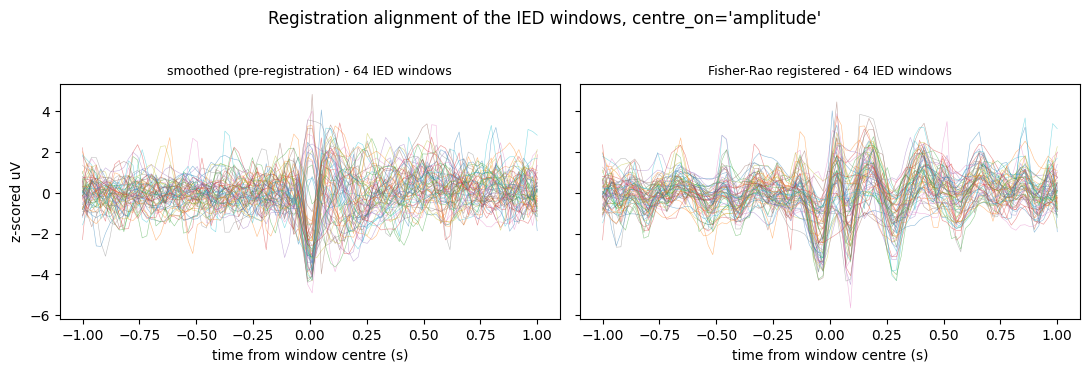

In [6]:
# do the positive windows stack once registered? (the curves the LR actually sees)
sm, al = pipe.classifier.aligned_curves(off[cfg.centre_on][0])
z = lambda A: (A - A.mean(1, keepdims=True)) / (A.std(1, keepdims=True) + 1e-12)
tt = np.linspace(-cfg.classifier_halfwin_s, cfg.classifier_halfwin_s, sm.shape[1])

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, A, ttl in ((axs[0], sm, 'smoothed (pre-registration)'), (axs[1], al, 'Fisher-Rao registered')):
    ax.plot(tt, z(A).T, lw=0.4, alpha=0.5)
    ax.set_title(f"{ttl} - {len(A)} IED windows", fontsize=9)
    ax.set_xlabel('time from window centre (s)')
axs[0].set_ylabel('z-scored uV')
plt.suptitle(f"Registration alignment of the IED windows, centre_on='{cfg.centre_on}'", y=1.02)
plt.tight_layout()
plt.savefig(f'../figures/detection_registration_alignment_{cfg.centre_on}.png', dpi=800, bbox_inches='tight')
plt.show()

### What this showed

**Measured under the earlier configuration** (`grouping='greedy'`, `corr=0.8`, `n_basis=30`,
`n_components=5`; 140 IED windows over 49 recordings), because that is when the question was settled:

| `centre_on` | median \|offset\| | p90 | max | >100 ms off | grouped-CV AUC |
|---|---|---|---|---|---|
| `'amplitude'` (default) | 54 ms | 154 ms | 238 ms | **22%** | **0.669** |
| `'sharpness'` | 20 ms | 86 ms | 152 ms | **1%** | 0.617 |

**The centring suspicion was real but harmless.** The amplitude rule genuinely did misalign a fifth of
the training positives — the centre jumped to the after-going slow wave (S65 +126 ms, S19 +160 ms) while
the marker sat on the sharp spike. Re-centring on the L1 sharpness statistic fixed the alignment almost
completely.

**But it did not raise the AUC.** Grouped 5-fold CV by recording over all train candidates: 0.669
amplitude vs 0.617 sharpness, with a recording-level bootstrap putting the difference at **+0.051 in
favour of amplitude, 95% CI [0.000, +0.105]**. Marker fidelity is not what the FDA features want —
plausibly because FPCA is amplitude-sensitive, so pinning the largest deflection at t=0 is the stronger
regularity, while Fisher-Rao warping absorbs the residual shift. **`centre_on` stays `'amplitude'`, and
centring is ruled out as the AUC bottleneck.**

**Under the current `'components'` grouping the misalignment largely fixed itself** — see the cell above:
median |offset| fell 54 → 26 ms and the >100 ms fraction 22% → 17%, with no change to the centring rule.
The representative channel is now chosen from the whole field rather than a fragment, so it lands on the
true dominant channel more often. That reinforces the decision rather than reopening it.

Two caveats for the writeup:
- **Don't score the centring rules by how tightly the windows stack.** That comparison is circular: each
  rule maximises self-similarity at its own centre, so the "tighter" overlay is the one that centres on
  the biggest deflection regardless of whether that is the IED. The offset to the neurologist marker is
  the only alignment measure here that uses information from outside the rule being tested.
- The registration overlay is a *sanity* check (do the curves stack on a common shape?), not a metric —
  Fisher-Rao elastic warping can absorb part of a centring error, which is exactly why the AUC effect had
  to be measured rather than inferred from the offsets.

In [7]:
print('=== TEST (10 recordings) ===')
E_te, S_te, Y_te, G_te = M.report(pipe, test)   # one L1+L2+L3 pass, reused by the plots below

=== TEST (10 recordings) ===
  L1 IED recall            : 1.00
  L2 consolidation recall  : 1.00
  L2 events                : 211/min, 1.00 per IED, 5.28 channels each
  L3 ROC-AUC / PR-AUC      : 0.847 / 0.094   (PR chance = 0.012)
  localisation error (ms)  : 4
  centre baseline          : sens 0.40, 4.0 FP/min  (to beat)
  FROC — best sensitivity at FP/min budget:
    <=   1 FP/min : sens 0.00
    <=   5 FP/min : sens 0.20
    <=  10 FP/min : sens 0.60
    <=  25 FP/min : sens 0.60
    <=  50 FP/min : sens 0.80
    <= 100 FP/min : sens 1.00
  operating point @ <= 10 FP/min (score >= 0.82):
    hits 3/5   misses 2   false positives 16 (7.9/min)


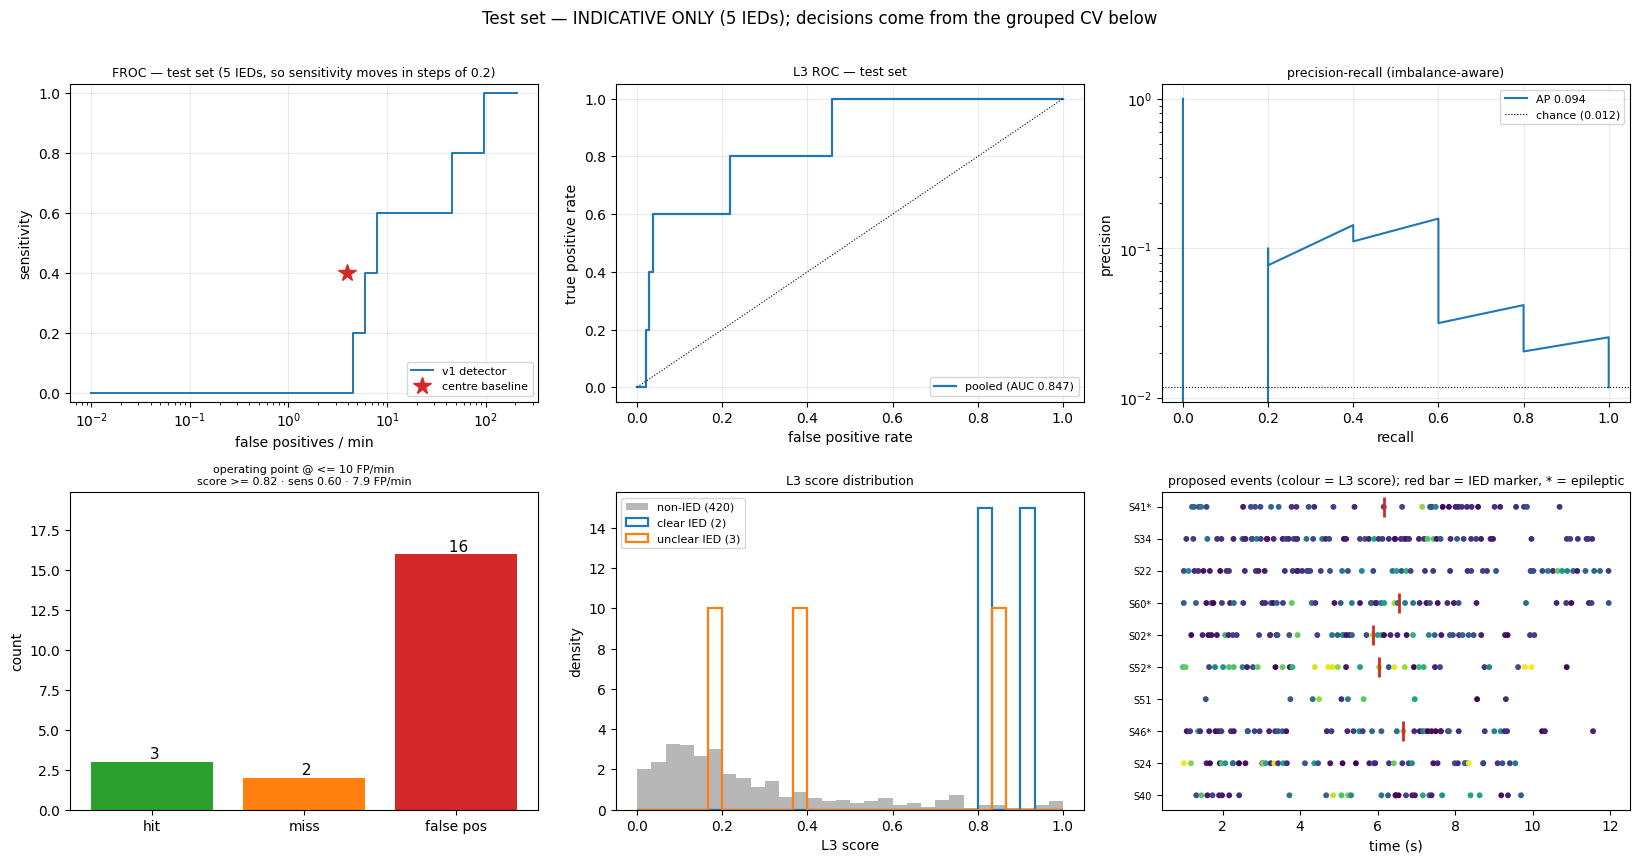

In [8]:
import detect_plots as P

pts_te = M.froc_points(test, E_te, G_te, S_te, cfg)
cm_te = M.detection_counts(test, E_te, G_te, S_te, cfg,
                           M.threshold_at(pts_te, M.FP_BUDGET))

fig, axs = plt.subplots(2, 3, figsize=(16.5, 8.5))
n_ied = sum(r['epi'] for r in test)
P.froc(axs[0, 0], pts_te, label='v1 detector', baseline=M.centre_baseline(test, cfg))
axs[0, 0].set_title(f'FROC — test set ({n_ied} IEDs, so sensitivity moves in steps '
                    f'of {1 / n_ied:.1f})', fontsize=9)
P.roc(axs[0, 1], Y_te, S_te)
axs[0, 1].set_title('L3 ROC — test set', fontsize=9)
P.pr(axs[0, 2], Y_te, S_te)
axs[0, 2].set_title('precision-recall (imbalance-aware)', fontsize=9)
P.counts(axs[1, 0], cm_te, f'operating point @ <= {M.FP_BUDGET:.0f} FP/min')
P.score_hist(axs[1, 1], Y_te, S_te, G_te, test)
axs[1, 1].set_title('L3 score distribution', fontsize=9)
P.timeline(axs[1, 2], test, E_te, G_te, S_te, cfg)
plt.suptitle('Test set — INDICATIVE ONLY (5 IEDs); decisions come from the grouped CV below', y=1.01)
plt.tight_layout()
plt.savefig('../figures/detection_test_metrics.png', dpi=800, bbox_inches='tight')
plt.show()

### Reading the result
- **L1/L2 recall = 1.0, localisation ~4 ms, 1.00 events per IED** → the front end finds, groups and
  localises every IED. It is not the problem.
- **L3 discrimination is the bottleneck.** Grouped-CV AUC on the 90-train is **0.657, 95% CI
  [0.582, 0.730]** (see the CV section below) — that is the number to quote, not the test AUC printed
  above, which comes from 5 IEDs and moves ±0.05 between configurations whose FROC is identical.
- **The cross-validated FROC is the honest system result:** sensitivity 0.04 @ 5 FP/min · 0.14 @ 10 ·
  0.35 @ 25 · 0.53 @ 50 · 0.69 @ 100, against a centre baseline of **0.29 @ 4 FP/min**. So at low
  false-alarm rates the detector is still *behind* "always guess the middle of the recording", and only
  overtakes it past ~10 FP/min. Published IED detectors report 0.7–0.9 at 0.5–5 FP/min.
- **Remaining levers**, in order: hard-negative mining at L3, then L4 spatial features (now viable — the
  `'components'` grouping recovers 15 of the 17 involved channels per IED instead of 6, so `n_channels`
  finally measures the discharge rather than a clustering artifact).
- **Random cropping** (vary the marker position at eval, min pre 2.33 s / post 5.08 s) is still owed — the
  centre baseline is inflated by the marker sitting mid-recording in ~99% of clips.
- Ship to supervisor: `../detect_model.joblib` + `predict.py` + `requirements.txt`.

## Grouped cross-validation on the 90-train (run on demand)

**This is where every tuning decision should be read from**, not from the test set above. The test split
holds ~5 IEDs, so its AUC swings ±0.05 between configurations whose FROC is identical — measured, see
report.md. Here the folds are **grouped by recording**, so the several events one IED spawns never land
on both sides of a split, and pooling the out-of-fold scores gives a FROC over all ~49 train IEDs
instead of 5.

**Independent cell:** nothing else in this notebook depends on it. Set `RUN_GROUPED_CV = True` to run it
(~15–20 min: one full L3 fit per fold).

In [9]:
RUN_GROUPED_CV = False         # ~15-20 min (one L3 fit per fold). Nothing below depends on this cell.

if RUN_GROUPED_CV:
    cv = M.grouped_cv(pipe, train)                       # out-of-fold scores over every train candidate
    lo, hi = M.bootstrap_auc_ci(cv['Y'], cv['G'], cv['scores'])
    pts = M.froc_points(train, cv['events'], cv['G'], cv['scores'], cfg)
    errs = M.localisation_errors(train, cv['events'], cv['G'], cv['scores'], cfg)
    cm = M.detection_counts(train, cv['events'], cv['G'], cv['scores'], cfg,
                            M.threshold_at(pts, M.FP_BUDGET))
    print(f"grouped-CV AUC {cv['auc']:.3f}  95% CI [{lo:.3f}, {hi:.3f}]   PR-AUC {cv['ap']:.3f}")
    print(f"per fold        {' · '.join(f'{f:.3f}' for f in cv['folds'])}")
    print(f"windows {len(cv['Y'])}, positives {cv['Y'].sum()}, "
          f"localisation median {np.median(errs):.0f} ms over {len(errs)} IEDs")
    print('cross-validated FROC — best sensitivity at FP/min budget:')
    for fp, sens in M.froc_summary(pts).items():
        print(f'    <= {fp:>3} FP/min : sens {sens:.2f}')
    print(f"operating point @ <= {M.FP_BUDGET:.0f} FP/min "
          f"(score >= {cm['threshold']:.2f}): hits {cm['hit']}/{cm['hit'] + cm['miss']}  "
          f"misses {cm['miss']}  false positives {cm['fp']} ({cm['fp_per_min']:.1f}/min)")

    fig, axs = plt.subplots(2, 4, figsize=(21, 8.5))
    P.froc(axs[0, 0], pts, label='out-of-fold', baseline=M.centre_baseline(train, cfg))
    axs[0, 0].set_title(f"cross-validated FROC — {sum(r['epi'] for r in train)} IEDs", fontsize=9)
    P.roc(axs[0, 1], cv['Y'], cv['scores'],
          folds=[(cv['Y'][cv['fold'] == k], cv['scores'][cv['fold'] == k])
                 for k in range(len(cv['folds']))])
    axs[0, 1].set_title('out-of-fold ROC (grey = individual folds)', fontsize=9)
    P.pr(axs[0, 2], cv['Y'], cv['scores'])
    axs[0, 2].set_title('precision-recall (imbalance-aware)', fontsize=9)
    P.counts(axs[0, 3], cm, f'operating point @ <= {M.FP_BUDGET:.0f} FP/min')
    P.fold_aucs(axs[1, 0], cv['folds'], cv['auc'])
    axs[1, 0].set_title('per-fold AUC vs pooled', fontsize=9)
    P.score_hist(axs[1, 1], cv['Y'], cv['scores'], cv['G'], train)
    axs[1, 1].set_title('out-of-fold score distribution', fontsize=9)
    P.loc_error(axs[1, 2], errs, cfg)
    axs[1, 2].set_title('localisation error', fontsize=9)
    axs[1, 3].axis('off')
    plt.suptitle(f"Grouped 5-fold CV on the 90-train — grouping='{cfg.grouping}', "
                 f"corr={cfg.corr_threshold}, n_basis={cfg.n_basis}, n_components={cfg.n_components}",
                 y=1.02)
    plt.tight_layout()
    plt.savefig('../figures/detection_grouped_cv.png', dpi=800, bbox_inches='tight')
    plt.show()

In [10]:
# n_components sweep. Registration is fitted ONCE per fold and reused, so every k after that is ~free.
n_components_sweep = False

if n_components_sweep:
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier

    KS = [2, 4, 6, 8, 12, 16, 24, 32]
    E, W, Y, G = M.labelled_events(pipe, train)
    clf = Classifier(cfg)
    scores = {k: np.zeros(len(Y)) for k in KS}

    for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(W, Y, G)):
        fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
        reg = FisherRaoElasticRegistration(penalty=cfg.penalty).fit(fds_tr)
        al_tr, al_te = reg.transform(fds_tr), reg.transform(fds_te)
        fpca = FPCA(n_components=max(KS)).fit(al_tr)
        P_tr, P_te = fpca.transform(al_tr), fpca.transform(al_te)
        for k in KS:
            sc = StandardScaler().fit(P_tr[:, :k])
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(sc.transform(P_tr[:, :k]), Y[tr])
            scores[k][te] = lr.predict_proba(sc.transform(P_te[:, :k]))[:, 1]
        print(f'fold {f} done', flush=True)

    print(f"{'k':>4} {'AUC':>7} {'95% CI':>18} {'sens@10':>8} {'sens@25':>8} {'sens@50':>8}")
    for k in KS:
        lo, hi = M.bootstrap_auc_ci(Y, G, scores[k], n_boot=500)
        fs = M.froc_summary(M.froc_points(train, E, G, scores[k], cfg))
        print(f"{k:>4} {roc_auc_score(Y, scores[k]):>7.3f}   [{lo:.3f}, {hi:.3f}]   "
            f"{fs[10]:>8.2f} {fs[25]:>8.2f} {fs[50]:>8.2f}")


In [11]:
if n_components_sweep:
    import joblib; joblib.dump({'KS': KS, 'scores': scores, 'Y': Y, 'G': G}, '/tmp/sweep_ncomp.joblib')
    for k in (4, 12, 16, 24, 32):
        fs = M.froc_summary(M.froc_points(train, E, G, scores[k], cfg))
        print(f"k={k:>3}  " + "  ".join(f"@{b}:{fs[b]:.2f}" for b in (1, 5, 10, 25, 50, 100)))
    print("centre baseline:", M.centre_baseline(train, cfg))


In [12]:
n_basis_sweep = False

if n_basis_sweep:

    from dataclasses import replace
    import joblib
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier
    BASES, KS = [30, 50, 70, 100], [8, 12, 16, 24, 32]
    E, W, Y, G = M.labelled_events(pipe, train)      # L1/L2 are independent of n_basis
    sweep = {}
    print(f"{'n_basis':>7} {'k':>4} {'AUC':>7} {'@5':>6} {'@10':>6} {'@25':>6}")
    for b in BASES:
        c = replace(cfg, n_basis=b)
        clf, ks = Classifier(c), [k for k in KS if k <= b - 2]   # can't keep more components than basis fns
        sc = {k: np.zeros(len(Y)) for k in ks}
        for tr, te in GroupKFold(n_splits=5).split(W, Y, G):
            fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
            reg = FisherRaoElasticRegistration(penalty=c.penalty).fit(fds_tr)
            al_tr, al_te = reg.transform(fds_tr), reg.transform(fds_te)
            fpca = FPCA(n_components=max(ks)).fit(al_tr)
            P_tr, P_te = fpca.transform(al_tr), fpca.transform(al_te)
            for k in ks:
                s = StandardScaler().fit(P_tr[:, :k])
                lr = LogisticRegression(C=c.lr_C, max_iter=1000, class_weight='balanced')
                lr.fit(s.transform(P_tr[:, :k]), Y[tr])
                sc[k][te] = lr.predict_proba(s.transform(P_te[:, :k]))[:, 1]
        for k in ks:
            fs = M.froc_summary(M.froc_points(train, E, G, sc[k], cfg), fp_targets=(5, 10, 25))
            print(f"{b:>7} {k:>4} {roc_auc_score(Y, sc[k]):>7.3f} {fs[5]:>6.2f} {fs[10]:>6.2f} "
                f"{fs[25]:>6.2f}", flush=True)
        sweep[b] = sc
    joblib.dump({'sweep': sweep, 'Y': Y, 'G': G}, '/tmp/sweep_basis.joblib')


In [13]:
# hard-negative-mining sweep. Mining only changes which rows the LR trains on, and it sits AFTER
# registration + FPCA, so every ratio shares one CV run — the same trick as the n_components sweep.
hard_neg_sweep = True

if hard_neg_sweep:
    from dataclasses import replace
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import roc_auc_score, average_precision_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier

    RATIOS = [0, 2, 5, 10, 20, 50]        # hardest negatives kept per positive; 0 = keep all (current)
    E, W, Y, G = M.labelled_events(pipe, train)
    clf = Classifier(cfg)
    sc = {r: np.zeros(len(Y)) for r in RATIOS}

    for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(W, Y, G)):
        fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
        reg = FisherRaoElasticRegistration(penalty=cfg.penalty).fit(fds_tr)
        fpca = FPCA(n_components=cfg.n_components).fit(reg.transform(fds_tr))
        P_tr, P_te = fpca.transform(reg.transform(fds_tr)), fpca.transform(reg.transform(fds_te))
        s = StandardScaler().fit(P_tr)
        Z_tr, Z_te = s.transform(P_tr), s.transform(P_te)
        lr0 = clf._fit_lr(Z_tr, Y[tr])                      # first pass: all negatives
        for r in RATIOS:
            if r == 0:
                lr = lr0
            else:
                c = Classifier(replace(cfg, hard_neg_ratio=r))
                c._lr = lr0                                  # mine against the first-pass ranking
                lr = c._fit_lr(*c._mine(Z_tr, Y[tr]))
            sc[r][te] = lr.predict_proba(Z_te)[:, 1]
        print(f'fold {f} done', flush=True)

    print(f"\n{'ratio':>6} {'ROC-AUC':>8} {'PR-AUC':>7} {'@5':>6} {'@10':>6} {'@25':>6}   "
          f"hits/misses/FP @ <= {M.FP_BUDGET:.0f} FP/min")
    for r in RATIOS:
        pts = M.froc_points(train, E, G, sc[r], cfg)
        fs = M.froc_summary(pts, fp_targets=(5, 10, 25))
        c = M.detection_counts(train, E, G, sc[r], cfg, M.threshold_at(pts, M.FP_BUDGET))
        print(f"{r:>6} {roc_auc_score(Y, sc[r]):>8.3f} {average_precision_score(Y, sc[r]):>7.3f} "
              f"{fs[5]:>6.2f} {fs[10]:>6.2f} {fs[25]:>6.2f}   "
              f"{c['hit']:>3} / {c['miss']:>3} / {c['fp']:>4}")
    print(f"(PR-AUC chance = {Y.mean():.3f};  centre baseline "
          f"{M.centre_baseline(train, cfg)[0]:.2f} @ {M.centre_baseline(train, cfg)[1]:.1f} FP/min)")


fold 0 done
fold 1 done
fold 2 done
fold 3 done
fold 4 done

 ratio  ROC-AUC  PR-AUC     @5    @10    @25   hits/misses/FP @ <= 10 FP/min
     0    0.828   0.117   0.41   0.59   0.71    29 /  20 /  176
     2    0.270   0.010   0.02   0.04   0.08     2 /  47 /  156
     5    0.431   0.014   0.02   0.04   0.18     2 /  47 /  185
    10    0.740   0.069   0.24   0.35   0.59    17 /  32 /  160
    20    0.823   0.145   0.43   0.59   0.76    29 /  20 /  145
    50    0.829   0.126   0.39   0.59   0.73    29 /  20 /  174
(PR-AUC chance = 0.015;  centre baseline 0.29 @ 4.0 FP/min)


In [14]:
from sklearn.metrics import average_precision_score
rng, groups, d = np.random.default_rng(0), np.unique(G), []
for _ in range(2000):
    idx = np.concatenate([np.where(G == k)[0] for k in rng.choice(groups, len(groups), replace=True)])
    if len(set(Y[idx].tolist())) > 1:
        d.append(average_precision_score(Y[idx], sc[20][idx])
                 - average_precision_score(Y[idx], sc[0][idx]))
d = np.array(d)
print(f"PR-AUC(ratio 20) - PR-AUC(all): {d.mean():+.3f}  "
      f"95% CI [{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]  P(>0)={np.mean(d > 0):.2f}")


PR-AUC(ratio 20) - PR-AUC(all): +0.027  95% CI [-0.008, +0.069]  P(>0)=0.94
